# Modelos de classificação com scikit-learn

Este notebook demonstra, **um modelo por seção**, classificadores usados com frequência em dados tabulares. O fluxo é igual para todos: preparar os dados, `fit(X_train, y_train)`, `predict(X_test)` e comparar métricas. Os hiperparâmetros exibidos são pontos de partida, não valores universais.

## Preparação comum

Usamos `load_breast_cancer`, dataset nativo do scikit-learn. No alvo original, `0` é maligno; invertemos a codificação para que `1` seja **maligno**, a classe positiva. Como falso negativo é especialmente indesejável nesse exemplo, recall será observado com atenção. O `StandardScaler` é ajustado explicitamente apenas no treino, para que fique visível quais modelos precisam de escala.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, average_precision_score,
    f1_score, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42


In [2]:
cancer = load_breast_cancer(as_frame=True)
X = cancer.data
y = (cancer.target == 0).astype(int)  # 1 = maligno; 0 = benigno

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)
print(f'Observações: {X.shape[0]} | Features: {X.shape[1]}')
print('Proporção de malignos — treino/teste:', f'{y_train.mean():.1%}', '/', f'{y_test.mean():.1%}')
display(X.head())


Observações: 569 | Features: 30
Proporção de malignos — treino/teste: 37.4% / 36.8%


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)
display(X_train_scaled.describe().loc[['mean', 'std']].round(2))


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
mean,-0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,0.0,0.0,-0.0,...,-0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Como a classificação vira métrica

A matriz de confusão separa verdadeiros positivos (TP), falsos positivos (FP), verdadeiros negativos (TN) e falsos negativos (FN). `accuracy` mede todos os acertos; `precision` mede a confiança de alertas positivos; `recall` mede quantos positivos reais foram encontrados; `F1` equilibra precision e recall. ROC-AUC e AP avaliam a ordenação de escores em vários limiares.

In [4]:
resultados = []

def avaliar_modelo(nome, modelo, X_avaliacao):
    y_pred = modelo.predict(X_avaliacao)
    if hasattr(modelo, 'predict_proba'):
        escores = modelo.predict_proba(X_avaliacao)[:, 1]
    else:
        escores = modelo.decision_function(X_avaliacao)
    resultados.append({'modelo': nome, 'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_test, escores),
        'average_precision': average_precision_score(y_test, escores)})
    return y_pred

def mostrar_matriz(y_pred, titulo):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['benigno', 'maligno'], cmap='Blues')
    plt.title(titulo)
    plt.show()


## 1. Baseline — `DummyClassifier`

Ignora as features e sempre prevê a classe mais frequente. Hiperparâmetro: `strategy`; use `most_frequent` como referência mínima. Em classes desbalanceadas, a accuracy pode parecer boa apesar de o recall da classe importante ser zero.

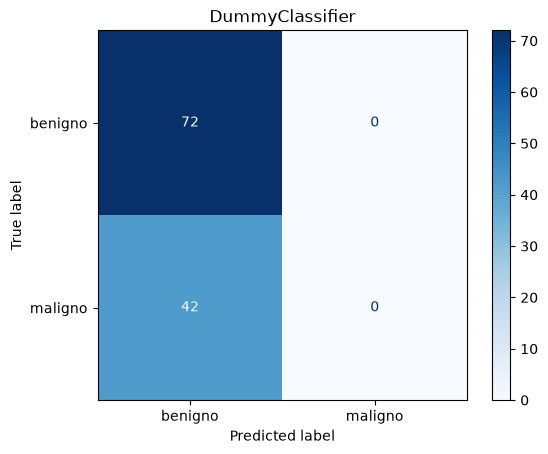

In [5]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_pred = avaliar_modelo('Dummy (classe mais frequente)', dummy, X_test)
mostrar_matriz(dummy_pred, 'DummyClassifier')


## 2. Regressão logística — `LogisticRegression`

Boa baseline probabilística e interpretável quando a fronteira é aproximadamente linear. Requer escala comparável. Hiperparâmetros: `C` controla a regularização (menor = mais regularização), `penalty` define L1/L2 e `class_weight='balanced'` pode ajudar em desbalanceamento. Use `max_iter` suficiente para convergência.

In [6]:
logistica = LogisticRegression(C=1.0, max_iter=2_000, random_state=RANDOM_STATE)
logistica.fit(X_train_scaled, y_train)
logistica_pred = avaliar_modelo('Logistic Regression', logistica, X_test_scaled)


## 3. Vizinhos próximos — `KNeighborsClassifier`

Indicado para padrões locais não lineares e conjuntos pequenos ou moderados. Exige escala. Hiperparâmetros: `n_neighbors` controla suavidade (maior = fronteira mais suave), `weights` define voto uniforme ou por distância, e `p` escolhe a distância de Minkowski (`p=2` é Euclidiana). A predição pode ser lenta em datasets grandes.

In [7]:
knn = KNeighborsClassifier(n_neighbors=7, weights='distance', p=2)
knn.fit(X_train_scaled, y_train)
knn_pred = avaliar_modelo('KNN (k=7)', knn, X_test_scaled)


## 4. Máquina de vetores de suporte — `SVC`

Útil para fronteiras complexas em datasets de tamanho moderado e muitas features. Exige escala. Hiperparâmetros: `C` equilibra margem e erros de treino, `kernel` escolhe a forma da fronteira e `gamma` controla o alcance do kernel RBF. `SVC` pode ser caro para grandes volumes; `LinearSVC` é a alternativa para fronteira linear e dados esparsos grandes.

In [8]:
svc = SVC(C=1.0, kernel='rbf', gamma='scale', random_state=RANDOM_STATE)
svc.fit(X_train_scaled, y_train)
svc_pred = avaliar_modelo('SVC (RBF)', svc, X_test_scaled)


## 5. Árvore de decisão — `DecisionTreeClassifier`

Boa para regras interpretáveis, interações e relações não lineares; não requer escala. Hiperparâmetros: `max_depth` limita complexidade, `min_samples_leaf` evita folhas muito específicas, `criterion` define a medida de divisão e `class_weight` ajusta o custo relativo das classes. Sem limites, árvores tendem a sobreajustar.

In [9]:
arvore = DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, random_state=RANDOM_STATE)
arvore.fit(X_train, y_train)
arvore_pred = avaliar_modelo('Decision Tree', arvore, X_test)


## 6. Random Forest — `RandomForestClassifier`

Baseline robusta para dados tabulares, capaz de capturar não linearidades e interações sem escala. Hiperparâmetros: `n_estimators` é o número de árvores, `max_depth` e `min_samples_leaf` regularizam cada árvore, e `max_features` controla as features candidatas em cada divisão. É menos interpretável que uma árvore única.

In [10]:
floresta = RandomForestClassifier(n_estimators=300, max_features='sqrt', min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1)
floresta.fit(X_train, y_train)
floresta_pred = avaliar_modelo('Random Forest', floresta, X_test)


## 7. Extra Trees — `ExtraTreesClassifier`

Ensemble de árvores ainda mais aleatorizado; frequentemente é uma boa alternativa rápida à Random Forest em dados tabulares. Não requer escala. Hiperparâmetros principais são os mesmos: `n_estimators`, `max_depth`, `min_samples_leaf` e `max_features`. Compare-o sob a mesma validação, pois desempenho varia com os dados.

In [11]:
extra_trees = ExtraTreesClassifier(n_estimators=300, max_features='sqrt', min_samples_leaf=2,
    random_state=RANDOM_STATE, n_jobs=-1)
extra_trees.fit(X_train, y_train)
extra_pred = avaliar_modelo('Extra Trees', extra_trees, X_test)


## 8. Gradient boosting por histogramas — `HistGradientBoostingClassifier`

Frequentemente forte em dados tabulares maiores, aprendendo árvores sequenciais que corrigem erros anteriores. Não exige escala. Hiperparâmetros: `learning_rate` reduz o passo de cada árvore, `max_iter` define quantas iterações são treinadas, `max_leaf_nodes` limita cada árvore e `l2_regularization` reduz overfitting. Comece simples e valide cuidadosamente.

In [12]:
boosting = HistGradientBoostingClassifier(learning_rate=0.08, max_iter=200, max_leaf_nodes=15,
    l2_regularization=1.0, random_state=RANDOM_STATE)
boosting.fit(X_train, y_train)
boosting_pred = avaliar_modelo('HistGradientBoosting', boosting, X_test)


## Comparação dos resultados

A tabela usa o mesmo teste para todos os modelos e é uma demonstração da API. Não ajuste parâmetros repetidamente olhando para esse teste; use validação cruzada no treino no módulo 004. A escolha deve considerar a métrica do problema, interpretabilidade, latência e estabilidade — não apenas a maior accuracy.

,modelo,accuracy,precision,recall,f1,roc_auc,average_precision
0,SVC (RBF),0.974,1.000,0.929,0.963,0.995,0.993
1,Random Forest,0.974,1.000,0.929,0.963,0.995,0.993
2,Logistic Regression,0.965,0.975,0.929,0.951,0.996,0.994
3,Extra Trees,0.965,1.000,0.905,0.950,0.999,0.998
4,HistGradientBoosting,0.965,1.000,0.905,0.950,0.994,0.992
5,KNN (k=7),0.956,0.974,0.905,0.938,0.983,0.979
6,Decision Tree,0.904,0.919,0.810,0.861,0.915,0.878
7,Dummy (classe mais frequente),0.632,0.000,0.000,0.000,0.500,0.368


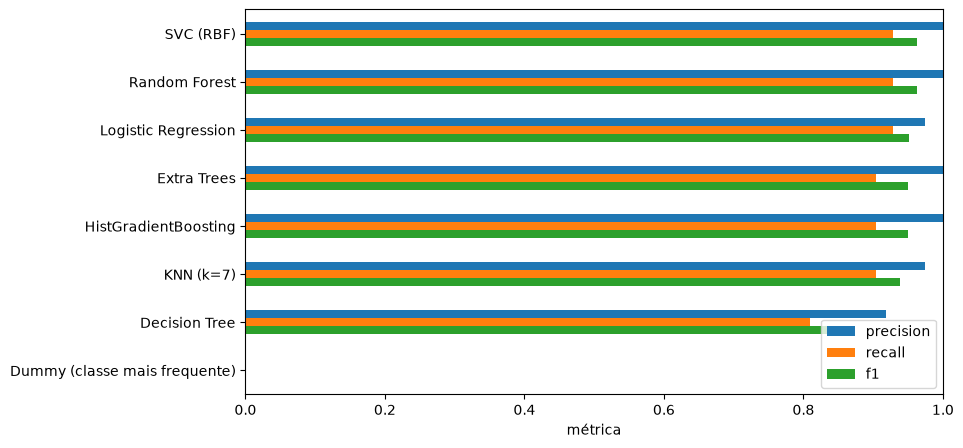

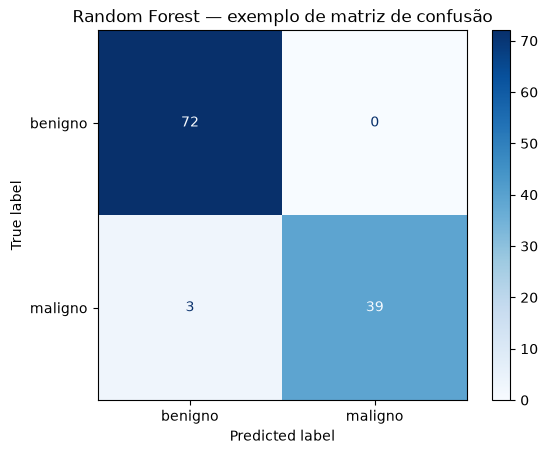

In [13]:
resultados_df = pd.DataFrame(resultados).sort_values('f1', ascending=False).reset_index(drop=True)
display(resultados_df.style.format({coluna: '{:.3f}' for coluna in resultados_df.columns[1:]}))
ax = resultados_df.plot.barh(x='modelo', y=['precision', 'recall', 'f1'], figsize=(9, 5))
ax.set(xlim=(0, 1), xlabel='métrica', ylabel='')
ax.invert_yaxis()
plt.show()
mostrar_matriz(floresta_pred, 'Random Forest — exemplo de matriz de confusão')


## Importância de features

Em ensembles de árvores, `feature_importances_` resume a redução de impureza. É uma leitura inicial útil, mas pode favorecer features contínuas ou com muitos valores; não prova causalidade. Para uma leitura ligada a uma métrica específica, use importância por permutação depois de validar o modelo.

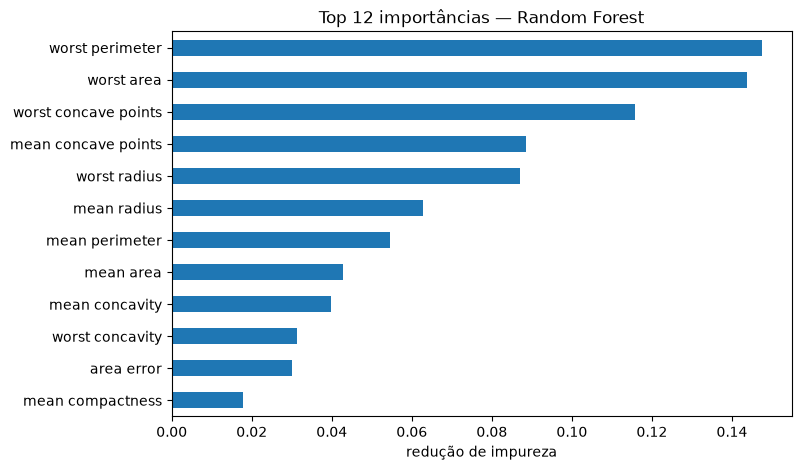

In [14]:
importancias = pd.Series(floresta.feature_importances_, index=X.columns).sort_values().tail(12)
importancias.plot.barh(figsize=(8, 5), title='Top 12 importâncias — Random Forest')
plt.xlabel('redução de impureza')
plt.show()


## Checklist antes de escolher

1. A classe positiva e o custo de falsos positivos/falsos negativos foram definidos?
2. A divisão foi estratificada e o scaler foi ajustado apenas no treino?
3. A baseline foi superada na métrica relevante?
4. Hiperparâmetros foram escolhidos por validação cruzada no treino?
5. O limiar de decisão foi revisado quando o custo dos erros exigir?

Para explicações, fórmulas e uma tabela de hiperparâmetros, consulte [`docs/002__CLASSIFICATION.md`](../docs/002__CLASSIFICATION.md).